In [1]:
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt


In [2]:
train_X = pd.read_csv('../../data/curated/damage/train_X.csv')
train_Y = pd.read_csv('../../data/curated/damage/train_Y.csv')
val_X = pd.read_csv('../../data/curated/damage/val_X.csv')
val_Y = pd.read_csv('../../data/curated/damage/val_Y.csv')
test_X = pd.read_csv('../../data/curated/damage/test_X.csv')
test_Y = pd.read_csv('../../data/curated/damage/test_Y.csv')

In [3]:
model = RandomForestRegressor(n_estimators=25, max_depth=8, max_samples=0.4, max_features=0.7, ccp_alpha=0.1)

In [4]:
model.fit(train_X, train_Y)

/var/folders/qx/w38nm8p540l84z4yf2h3sm2h0000gn/T/ipykernel_24822/3051844655.py:1: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model.fit(train_X, train_Y)


RandomForestRegressor(ccp_alpha=0.1, max_depth=8, max_features=0.7,
                      max_samples=0.4, n_estimators=25)

In [5]:
pred_Y = model.predict(test_X)

In [6]:
r2_score(y_pred=pred_Y, y_true=test_Y), mean_squared_error(pred_Y, test_Y)

(0.7642409711112212, 16881.850703278098)

In [7]:
importance_df = pd.DataFrame(data= [model.feature_importances_], columns=train_X.columns)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51],
 [Text(0, 0, 'regulated_dam'),
  Text(1, 0, 'height'),
  Text(2, 0, 'length'),
  Text(3, 0, 'volume'),
  Text(4, 0, 'surface'),
  Text(5, 0, 'drainage'),
  Text(6, 0, 'inspection_frequency'),
  Text(7, 0, 'distance_to_nearest_city'),
  Text(8, 0, 'hazard'),
  Text(9, 0, 'probability_of_failure'),
  Text(10, 0, 'age'),
  Text(11, 0, 'modification_count'),
  Text(12, 0, 'years_from_modification'),
  Text(13, 0, 'years_from_inspection'),
  Text(14, 0, 'years_from_assessment'),
  Text(15, 0, 'region_Flumevale'),
  Text(16, 0, 'region_Lyndrassia'),
  Text(17, 0, 'region_Navaldia'),
  Text(18, 0, 'primary_purpose_Debris Control'),
  Text(19, 0, 'primary_purpose_Fire Protection, Stock, Or Small 

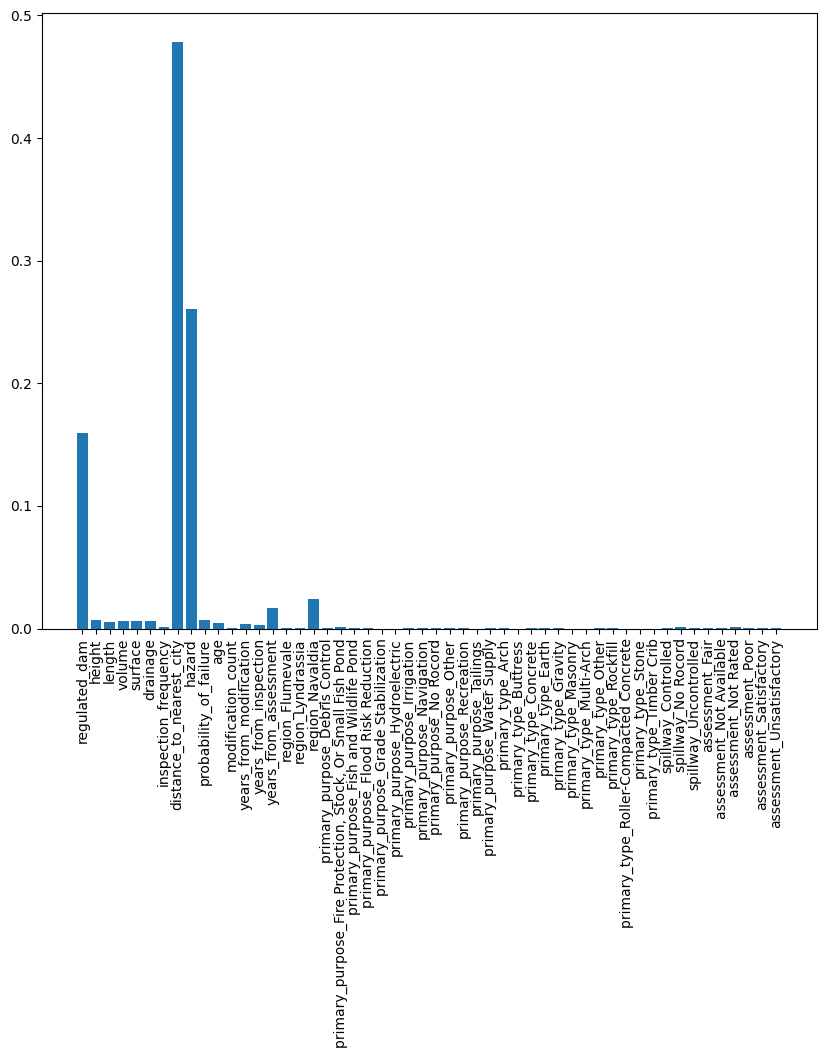

In [8]:
plt.figure(figsize=(10, 8))
plt.bar(x=train_X.columns, height=model.feature_importances_)
plt.xticks(rotation=90)